In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Electric_Production.csv to Electric_Production.csv


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("Electric_Production.csv")

data = df.iloc[:, 1].values

data = (data - np.mean(data)) / np.std(data)

In [9]:
def create_sequences(data, window_size, horizon):
    X, y = [], []


    for i in range(len(data) - window_size - horizon + 1):


        X.append(data[i:i+window_size])


        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)


window_size = 9
prediction_horizon = 1

X, y = create_sequences(data, window_size, prediction_horizon)

In [10]:
import torch


split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

X_train = X_train.unsqueeze(-1)
X_test = X_test.unsqueeze(-1)

GRU

In [11]:
import torch
import torch.nn as nn

class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.Wz = nn.Linear(input_size, hidden_size)
        self.Uz = nn.Linear(hidden_size, hidden_size)

        self.Wr = nn.Linear(input_size, hidden_size)
        self.Ur = nn.Linear(hidden_size, hidden_size)

        self.Wh = nn.Linear(input_size, hidden_size)
        self.Uh = nn.Linear(hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, input_size = x.shape

        h = torch.zeros(batch_size, self.hidden_size)

        for t in range(seq_len):
            xt = x[:, t, :]


            z = torch.sigmoid(self.Wz(xt) + self.Uz(h))


            r = torch.sigmoid(self.Wr(xt) + self.Ur(h))


            h_tilde = torch.tanh(self.Wh(xt) + self.Uh(r * h))


            h = (1 - z) * h + z * h_tilde

        out = self.fc(h)
        return out

In [12]:

model = CustomGRU(input_size=1, hidden_size=14, output_size=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
losses = []

model.train()

for epoch in range(50):
    optimizer.zero_grad()

    output = model(X_train)

    y_target = y_train.squeeze(-1)

    loss = criterion(output, y_target)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([310])) that is different to the input size (torch.Size([310, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 1.0740442276000977
Epoch 10, Loss: 0.98170006275177
Epoch 20, Loss: 0.9217908382415771
Epoch 30, Loss: 0.8873006701469421
Epoch 40, Loss: 0.8705307245254517


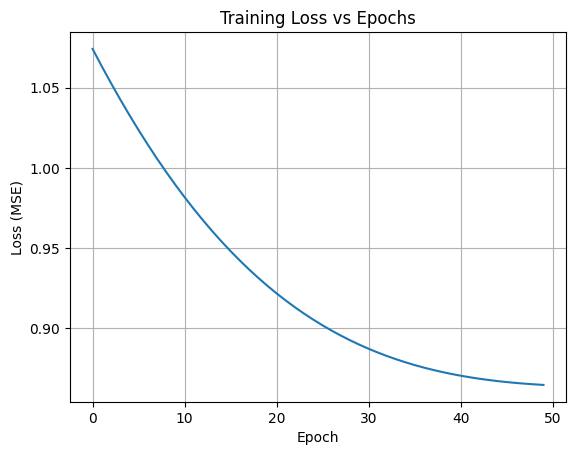

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid()

plt.show()

In [15]:
model.eval()

with torch.no_grad():
    preds = model(X_test).cpu().numpy()
    actual = y_test.cpu().numpy()


preds = preds.flatten()
actual = actual.flatten()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(actual, preds)
mae = mean_absolute_error(actual, preds)
rmse = np.sqrt(mse)

print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


MSE  : 1.3982
MAE  : 1.0045
RMSE : 1.1825


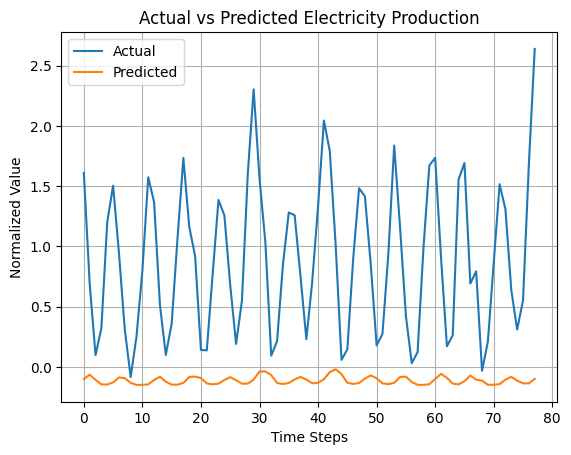

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(actual, label="Actual")
plt.plot(preds, label="Predicted")

plt.title("Actual vs Predicted Electricity Production")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid()

plt.show()

MLP

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):

        x = x.view(x.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))

In [19]:
mlp = MLP(9, 1)

optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)
criterion = nn.MSELoss()

mlp_losses = []
mlp.train()

for epoch in range(50):
    optimizer.zero_grad()

    output = mlp(X_train)
    y_target = y_train.squeeze(-1)

    loss = criterion(output, y_target)

    loss.backward()
    optimizer.step()

    mlp_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.1490412950515747
Epoch 10, Loss: 0.9901094436645508
Epoch 20, Loss: 0.9137718677520752
Epoch 30, Loss: 0.8928815126419067
Epoch 40, Loss: 0.8891122341156006


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([310])) that is different to the input size (torch.Size([310, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mlp.eval()

with torch.no_grad():
    mlp_preds = mlp(X_test).cpu().numpy()
    actual = y_test.cpu().numpy()

mlp_preds = mlp_preds.flatten()
actual = actual.flatten()

mse = mean_squared_error(actual, mlp_preds)
mae = mean_absolute_error(actual, mlp_preds)
rmse = np.sqrt(mse)

print("MLP Results:")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MLP Results:
MSE  : 1.7107
MAE  : 1.1408
RMSE : 1.3079


LTSM

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        return self.fc(out)

In [22]:
lstm = LSTMModel(input_size=1, hidden_size=14, output_size=1)
lstm_losses = []
lstm.train()

optimizer = torch.optim.Adam(lstm.parameters(), lr=0.001)

for epoch in range(50):
    optimizer.zero_grad()

    output = lstm(X_train)                  # (batch, 1)
    y_target = y_train.squeeze(-1)          # ensure shape match

    loss = criterion(output, y_target)

    loss.backward()
    optimizer.step()

    lstm_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([310])) that is different to the input size (torch.Size([310, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 0.8651336431503296
Epoch 10, Loss: 0.8631106019020081
Epoch 20, Loss: 0.8631219267845154
Epoch 30, Loss: 0.8630653023719788
Epoch 40, Loss: 0.8630306720733643


TRANSFORMER MODEL

In [23]:
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.embedding = nn.Linear(input_size, hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        x = self.embedding(x)

        x = self.transformer(x)

        # take last timestep
        x = x[:, -1, :]

        return self.fc(x)

In [24]:
transformer = TransformerModel(input_size=1, hidden_size=14, output_size=1)
transformer_losses = []
transformer.train()

optimizer = torch.optim.Adam(transformer.parameters(), lr=0.001)

for epoch in range(50):
    optimizer.zero_grad()

    output = transformer(X_train)          # (batch, 1)
    y_target = y_train.squeeze(-1)         # fix shape

    loss = criterion(output, y_target)

    loss.backward()
    optimizer.step()

    transformer_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.7039697170257568
Epoch 10, Loss: 0.8986468315124512
Epoch 20, Loss: 0.8821824789047241
Epoch 30, Loss: 0.8743306994438171
Epoch 40, Loss: 0.8684508204460144


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        preds = model(X_test).cpu().numpy()
        actual = y_test.cpu().numpy()

    # fix shapes
    preds = preds.flatten()
    actual = actual.flatten()

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse

In [26]:
print("GRU:", evaluate(model, X_test, y_test))
print("MLP:", evaluate(mlp, X_test, y_test))
print("LSTM:", evaluate(lstm, X_test, y_test))
print("Transformer:", evaluate(transformer, X_test, y_test))

GRU: (1.398220419883728, 1.004510760307312, np.float64(1.182463707639151))
MLP: (1.7106671333312988, 1.140830159187317, np.float64(1.307924742992233))
LSTM: (1.5317662954330444, 1.0695728063583374, np.float64(1.2376454643527945))
Transformer: (1.5424911975860596, 1.0717544555664062, np.float64(1.2419706911139488))


In [27]:
def run_experiment(window_size, prediction_horizon, hidden_size):

    # create sequences
    X, y = create_sequences(data, window_size, prediction_horizon)

    split = int(0.8 * len(X))

    X_train = torch.tensor(X[:split], dtype=torch.float32)
    y_train = torch.tensor(y[:split], dtype=torch.float32)
    X_test = torch.tensor(X[split:], dtype=torch.float32)
    y_test = torch.tensor(y[split:], dtype=torch.float32)

    X_train = X_train.unsqueeze(-1)
    X_test = X_test.unsqueeze(-1)

    model = CustomGRU(input_size=1, hidden_size=hidden_size, output_size=prediction_horizon)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    model.train()

    for epoch in range(50):
        optimizer.zero_grad()

        output = model(X_train)
        y_target = y_train.squeeze(-1)

        loss = criterion(output, y_target)

        loss.backward()
        optimizer.step()

    return evaluate(model, X_test, y_test)

In [28]:
prediction_horizon = 1
hidden_size = 14

print("Window 4:", run_experiment(4, prediction_horizon, hidden_size))
print("Window 9:", run_experiment(9, prediction_horizon, hidden_size))
print("Window 18:", run_experiment(18, prediction_horizon, hidden_size))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([314])) that is different to the input size (torch.Size([314, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Window 4: (1.5034641027450562, 1.0554896593093872, np.float64(1.2261582698595872))


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([310])) that is different to the input size (torch.Size([310, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Window 9: (1.5619477033615112, 1.0818647146224976, np.float64(1.2497790618191327))


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([303])) that is different to the input size (torch.Size([303, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Window 18: (1.4279733896255493, 1.015257477760315, np.float64(1.1949784055059527))
